# View RB (DakisSX) results

Loads a saved `rb_*.json` file from `Results/RB/` and re-derives everything — fits,
EPC, fidelity, plots — from the raw per-circuit probability arrays it contains, purely
offline (no hardware calls, no Pulla/qiskit-IQM imports needed). This is the
reproduce/post-process companion to the RB notebooks that generated the data, the same
role `view_QPT_results.ipynb` plays for the QPT files.

Because each save file has raw per-circuit `probs` + `lengths_per_circ` (not just the
already-fitted alpha/EPC numbers), you can re-group, refit with a different length
subset, or recompute EPC/fidelity here without re-running anything on hardware.

Each file may contain some subset of these sections (guarded individually below, so
cells for missing sections just print a note and skip):
- `dakis_baseline` / `native_baseline` — standard + interleaved RB (SRB/IRB) for the
  DakisSX pulse and the machine's native SX gate, at zero detuning.
- `noisy_dakis_sx_detuning_sweep` / `noisy_native_sx_detuning_sweep` — IRB repeated
  under an added LO-frequency detuning sweep, to characterize detuning sensitivity.


In [1]:
import json, glob, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


In [2]:
# ── rb_fit / irb_epc_gate ────────────────────────────────────────────────────────────
# Pure numpy/scipy -- no hardware dependency, so this reproduces the original
# fit exactly given the same raw probs + lengths_per_circ.
def _group_probs(lengths_per_circ, probs, lengths):
    """Group P(|0>) results by sequence length; return (mean, stderr) arrays."""
    by_len = {m: [] for m in lengths}
    for m, p in zip(lengths_per_circ, probs):
        if m in by_len:
            by_len[m].append(p)
    means   = np.array([np.nanmean(by_len[m]) for m in lengths])
    stderrs = np.array([np.nanstd(by_len[m]) / np.sqrt(len(by_len[m])) if len(by_len[m]) > 1 else 0.0
                        for m in lengths])
    return means, stderrs


def rb_fit(lengths, lengths_per_circ, probs):
    """Fit P(|0>) = A * alpha^m + B. Returns dict with alpha, alpha_err, A, B,
    epc, epc_err, probs_mean, probs_std."""
    means, stderrs = _group_probs(lengths_per_circ, probs, lengths)

    valid = ~np.isnan(means)
    if not valid.all():
        bad = [ell for ell, ok in zip(lengths, valid) if not ok]
        print(f'  rb_fit WARNING: no valid data for length(s) {bad} -- '
              f'fitting on remaining {int(valid.sum())}/{len(lengths)} points')
    if valid.sum() < 3:
        raise RuntimeError(f'rb_fit: only {int(valid.sum())} valid length(s) -- need >=3 to fit.')

    fit_lengths = np.asarray(lengths)[valid]
    fit_means   = means[valid]
    fit_stderrs = stderrs[valid]

    def model(m, A, alpha, B):
        return A * alpha**m + B

    p0 = [0.5, 0.95, 0.5]
    popt, pcov = curve_fit(model, fit_lengths, fit_means,
                           p0=p0, sigma=fit_stderrs + 1e-6, absolute_sigma=True,
                           bounds=([0, 0, 0], [1, 1, 1]))
    perr = np.sqrt(np.diag(pcov))
    A, alpha, B = popt

    if alpha < 1e-3 or alpha > 1 - 1e-3:
        print(f'  rb_fit WARNING: alpha={alpha:.6f} is right at a fit bound -- '
              f'likely a degenerate fit; do not trust EPC/EPC_err.')

    d   = 2  # single qubit
    epc     = (d - 1) / d * (1 - alpha)
    epc_err = (d - 1) / d * perr[1]

    return dict(alpha=alpha, alpha_err=perr[1], A=A, B=B,
                epc=epc, epc_err=epc_err,
                probs_mean=means, probs_std=stderrs)


def irb_epc_gate(fit_ref, fit_int):
    """EPC_gate = (d-1)/d * (1 - alpha_int/alpha_ref) with error propagation."""
    d   = 2
    r   = fit_int['alpha'] / fit_ref['alpha']
    epc = (d - 1) / d * (1 - r)
    err = (d - 1) / d * r * np.sqrt(
        (fit_int['alpha_err'] / fit_int['alpha'])**2 +
        (fit_ref['alpha_err'] / fit_ref['alpha'])**2)
    return epc, err

print('rb_fit / irb_epc_gate ready.')


rb_fit / irb_epc_gate ready.


In [3]:
# ── discover saved RB result files ──────────────────────────────────────────────────
RESULTS_DIR = 'Results/RB'

files = sorted(glob.glob(os.path.join(RESULTS_DIR, 'rb_*.json')), key=os.path.getmtime)

print(f'{len(files)} file(s) found:\n')
for i, f in enumerate(files):
    with open(f) as fp:
        d = json.load(fp)
    sections = [s for s in ('dakis_baseline', 'native_baseline',
                            'noisy_dakis_sx_detuning_sweep', 'noisy_native_sx_detuning_sweep') if s in d]
    print(f"[{i}]  {os.path.basename(f)}")
    print(f"      qubit={d.get('qubit','N/A')},  machine={d.get('machine','N/A')},  "
          f"timestamp={str(d.get('timestamp','N/A'))[:19]}")
    print(f"      sections: {sections}\n")


4 file(s) found:

[0]  rb_sx_native_QB2_garnet_20260716_164323.json
      qubit=QB2,  machine=garnet,  timestamp=2026-07-16T16:43:23
      sections: ['noisy_native_sx_detuning_sweep']

[1]  rb_dakis_sx_QB7_garnet_20260718_193013.json
      qubit=QB7,  machine=garnet,  timestamp=2026-07-18T19:30:13
      sections: ['dakis_baseline', 'native_baseline', 'noisy_dakis_sx_detuning_sweep']

[2]  rb_dakis_sx_QB7_garnet_20260718_202929.json
      qubit=QB7,  machine=garnet,  timestamp=2026-07-18T20:29:29
      sections: ['dakis_baseline', 'native_baseline', 'noisy_dakis_sx_detuning_sweep', 'noisy_native_sx_detuning_sweep']

[3]  rb_dakis_sx_QB47_emerald_20260718_225105.json
      qubit=QB47,  machine=emerald,  timestamp=2026-07-18T22:51:05
      sections: ['dakis_baseline', 'native_baseline', 'noisy_dakis_sx_detuning_sweep']



In [4]:
# ── select file + load ───────────────────────────────────────────────────────────────
idx = 2   # -1 = most recent; idx=2 has both baseline + both detuning sweeps

with open(files[idx]) as f:
    record = json.load(f)

qbt_name    = record['qubit']
machine     = record['machine']
rb_lengths  = record['rb_params']['rb_lengths']
lengths_per_circ = record['lengths_per_circ']

print(f"File:      {os.path.basename(files[idx])}")
print(f"qubit:     {qbt_name}")
print(f"machine:   {machine}")
print(f"timestamp: {record['timestamp'][:19]}")
print(f"rb_lengths: {rb_lengths}")
print(f"rb_num_samples: {record['rb_params']['rb_num_samples']}   n_shots: {record['rb_params']['n_shots']}")

if 'dakis_calibration' in record:
    Texp = record['dakis_calibration']['Texp_ns']
    print(f"DakisSX Texp_ns: {Texp}")
if 'native_gate_calibration' in record:
    print(f"Native gate: {record['native_gate_calibration']['implementation']}  "
          f"({record['native_gate_calibration']['duration']*1e9:.0f} ns)")


File:      rb_dakis_sx_QB7_garnet_20260718_202929.json
qubit:     QB7
machine:   garnet
timestamp: 2026-07-18T20:29:29
rb_lengths: [1, 10, 30, 60, 100, 150, 200, 500]
rb_num_samples: 15   n_shots: 1000
DakisSX Texp_ns: 40.0
Native gate: drag_crf_sx  (16 ns)


SRB (DakisSX):  alpha=0.99636  EPC=1.8177e-03 +/- 1.1e-04  Fidelity=0.99818
  (saved fit for comparison: alpha=0.99636, epc=1.8177e-03)

IRB reference (DakisSX):     alpha=0.99627
IRB interleaved (DakisSX):   alpha=0.99279
EPC_DakisSX = 1.7502e-03 +/- 1.7e-04   Fidelity_DakisSX = 0.99825
  (saved fit for comparison: epc_dakis=1.7502e-03)


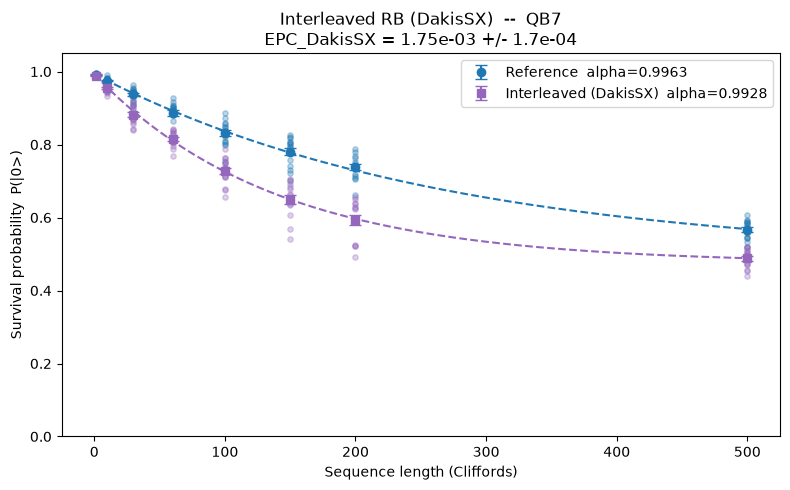

In [5]:
# ── Reproduce: DakisSX SRB + IRB from raw saved probs ───────────────────────────────
if 'dakis_baseline' in record:
    db = record['dakis_baseline']

    srb_fit_dakis = rb_fit(rb_lengths, lengths_per_circ['srb'], db['srb']['probs'])
    print(f'SRB (DakisSX):  alpha={srb_fit_dakis["alpha"]:.5f}  '
          f'EPC={srb_fit_dakis["epc"]:.4e} +/- {srb_fit_dakis["epc_err"]:.1e}  '
          f'Fidelity={1 - srb_fit_dakis["epc"]:.5f}')
    print(f'  (saved fit for comparison: alpha={db["srb"]["fit"]["alpha"]:.5f}, '
          f'epc={db["srb"]["fit"]["epc"]:.4e})')

    irb_ref_fit_dakis = rb_fit(rb_lengths, lengths_per_circ['irb_ref'], db['irb']['ref']['probs'])
    irb_int_fit_dakis = rb_fit(rb_lengths, lengths_per_circ['irb_int'], db['irb']['int']['probs'])
    epc_dakis_sx, epc_dakis_sx_err = irb_epc_gate(irb_ref_fit_dakis, irb_int_fit_dakis)
    fidelity_dakis_sx = 1 - epc_dakis_sx

    print(f'\nIRB reference (DakisSX):     alpha={irb_ref_fit_dakis["alpha"]:.5f}')
    print(f'IRB interleaved (DakisSX):   alpha={irb_int_fit_dakis["alpha"]:.5f}')
    print(f'EPC_DakisSX = {epc_dakis_sx:.4e} +/- {epc_dakis_sx_err:.1e}   '
          f'Fidelity_DakisSX = {fidelity_dakis_sx:.5f}')
    print(f'  (saved fit for comparison: epc_dakis={db["irb"]["epc_dakis"]:.4e})')

    m_fine = np.linspace(0, max(rb_lengths), 400)
    fig, ax = plt.subplots(figsize=(8, 5))
    for probs_all, lpc, fit, label, color, fmt in [
        (db['irb']['ref']['probs'], lengths_per_circ['irb_ref'], irb_ref_fit_dakis, 'Reference', 'tab:blue', 'o'),
        (db['irb']['int']['probs'], lengths_per_circ['irb_int'], irb_int_fit_dakis, 'Interleaved (DakisSX)', 'tab:purple', 's'),
    ]:
        for m, p in zip(lpc, probs_all):
            ax.scatter(m, p, s=15, alpha=0.3, color=color)
        ax.errorbar(rb_lengths, fit['probs_mean'], yerr=fit['probs_std'],
                    fmt=fmt, color=color, capsize=4, label=f'{label}  alpha={fit["alpha"]:.4f}')
        ax.plot(m_fine, fit['A'] * fit['alpha']**m_fine + fit['B'], '--', color=color)
    ax.set_xlabel('Sequence length (Cliffords)')
    ax.set_ylabel('Survival probability  P(|0>)')
    ax.set_title(f'Interleaved RB (DakisSX)  --  {qbt_name}\nEPC_DakisSX = {epc_dakis_sx:.2e} +/- {epc_dakis_sx_err:.1e}')
    ax.set_ylim(0.0, 1.05)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No 'dakis_baseline' section in this file.")


  rb_fit WARNING: alpha=0.999053 is right at a fit bound -- likely a degenerate fit; do not trust EPC/EPC_err.
SRB (native SX):  alpha=0.99905  EPC=4.7347e-04 +/- 1.1e-04  Fidelity=0.99953

IRB reference (native):      alpha=0.99816
IRB interleaved (native SX): alpha=0.99704
EPC_SX (native) = 5.6131e-04 +/- 1.3e-04   Fidelity_SX (native) = 0.99944


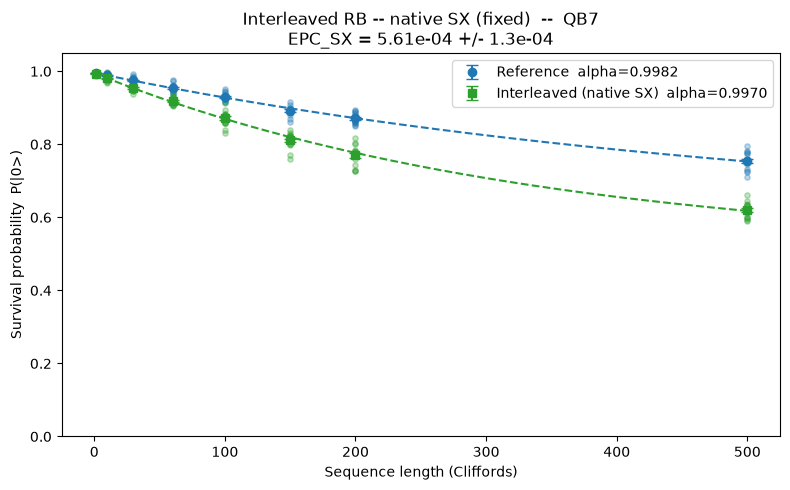

In [6]:
# ── Reproduce: native SX (fixed) SRB + IRB from raw saved probs ────────────────────
if 'native_baseline' in record:
    nb_ = record['native_baseline']

    srb_fit_native = rb_fit(rb_lengths, lengths_per_circ['srb'], nb_['srb']['probs'])
    print(f'SRB (native SX):  alpha={srb_fit_native["alpha"]:.5f}  '
          f'EPC={srb_fit_native["epc"]:.4e} +/- {srb_fit_native["epc_err"]:.1e}  '
          f'Fidelity={1 - srb_fit_native["epc"]:.5f}')

    irb_ref_fit_native = rb_fit(rb_lengths, lengths_per_circ['irb_ref'], nb_['irb']['ref']['probs'])
    irb_int_fit_native = rb_fit(rb_lengths, lengths_per_circ['irb_int'], nb_['irb']['int']['probs'])
    epc_sx_native, epc_sx_native_err = irb_epc_gate(irb_ref_fit_native, irb_int_fit_native)
    fidelity_sx_native = 1 - epc_sx_native

    print(f'\nIRB reference (native):      alpha={irb_ref_fit_native["alpha"]:.5f}')
    print(f'IRB interleaved (native SX): alpha={irb_int_fit_native["alpha"]:.5f}')
    print(f'EPC_SX (native) = {epc_sx_native:.4e} +/- {epc_sx_native_err:.1e}   '
          f'Fidelity_SX (native) = {fidelity_sx_native:.5f}')

    m_fine = np.linspace(0, max(rb_lengths), 400)
    fig, ax = plt.subplots(figsize=(8, 5))
    for probs_all, lpc, fit, label, color, fmt in [
        (nb_['irb']['ref']['probs'], lengths_per_circ['irb_ref'], irb_ref_fit_native, 'Reference', 'tab:blue', 'o'),
        (nb_['irb']['int']['probs'], lengths_per_circ['irb_int'], irb_int_fit_native, 'Interleaved (native SX)', 'tab:green', 's'),
    ]:
        for m, p in zip(lpc, probs_all):
            ax.scatter(m, p, s=15, alpha=0.3, color=color)
        ax.errorbar(rb_lengths, fit['probs_mean'], yerr=fit['probs_std'],
                    fmt=fmt, color=color, capsize=4, label=f'{label}  alpha={fit["alpha"]:.4f}')
        ax.plot(m_fine, fit['A'] * fit['alpha']**m_fine + fit['B'], '--', color=color)
    ax.set_xlabel('Sequence length (Cliffords)')
    ax.set_ylabel('Survival probability  P(|0>)')
    ax.set_title(f'Interleaved RB -- native SX (fixed)  --  {qbt_name}\nEPC_SX = {epc_sx_native:.2e} +/- {epc_sx_native_err:.1e}')
    ax.set_ylim(0.0, 1.05)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No 'native_baseline' section in this file.")
